# Pandas Exercises

## Creating DataFrames and Using Sample Data Sets

This is the Jupyter Notebook runnable exercises version of the article, [Pandas Practice Questions – Fifty-Two Examples to Make You an Expert](https://codesolid.com/pandas-practice-questions-twenty-one-examples-to-make-you-an-expert/).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb

**1.** Using NumPy, create a Pandas DataFrame with five rows and three columms:

In [5]:
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15]])
arr_pandas=pd.DataFrame(data,columns=['A','B','C'])
print(arr_pandas)

    A   B   C
0   1   2   3
1   4   5   6
2   7   8   9
3  10  11  12
4  13  14  15


**2.** For a Pandas DataFrame created from a NumPy array, what is the default behavior for the labels for the columns?  For the rows?

**3.** Create a second DataFrame as above with five rows and three columns, setting the row labels to the names of any five major US cities and the column labels to the first three months of the year.

In [6]:
import pandas as pd
import numpy as np

# Create a NumPy array with 5 rows and 3 columns
array = np.array([[10, 20, 30],
                  [15, 25, 35],
                  [12, 22, 32],
                  [18, 28, 38],
                  [14, 24, 34]])

# Create DataFrame with custom row and column labels
df = pd.DataFrame(array,
                  index=['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
                  columns=['January', 'February', 'March'])
#df.loc[:'Chicago',['January','February','March']]
january_sorted = df['January'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
january_sorted.plot(kind='barh', color='coral')
plt.title('Valores de January (Ordenados de Mayor a Menor)', fontsize=14, fontweight='bold')
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Ciudades', fontsize=12)
plt.tight_layout()
plt.show()



NameError: name 'plt' is not defined

**4.** You recall that the Seaborn package has some data sets built in, but can't remember how to list and load them. Assuming the functions to do so have "data" in the name, how might you locate them?  You can assume a Jupyter Notebook / IPython environment and explain the process, or write the code to do it in Python.

## Loading data from CSV

**5**. Zillow home data is available at this URL: https://files.zillowstatic.com/research/public_csvs/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv

Open this file as a DataFrame named df_homes in Pandas.

In [7]:
df_homes=pd.read_csv('https://files.zillowstatic.com/research/public_csvs/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')

df_homes.dropna(inplace=True)
#df_nulls=df_homes[df_homes.isna().any(axis=1)]
df.duplicated().sum()

np.int64(0)

**6.** Save the DataFrame, df_homes, to a local CSV file, "zillow_home_data.csv".  

In [8]:
df_homes.to_csv('zillow_home_data.csv', index=False)

**7.** Load zillow_home_data.csv back into a new Dataframe, df_homes_2

In [9]:
df_homes_2=pd.read_csv('zillow_home_data.csv')

**8.** Compare the dimensions of the two DataFrames, df_homes and df_homes_2.  Are they equal?  If not, how can you fix it?

In [10]:
df_homes.shape==df_homes_2.shape

True

**9.** A remote spreadsheet showing how a snapshot of how traffic increased for a hypothetical website is available here: https://github.com/CodeSolid/CodeSolid.github.io/raw/main/booksource/data/AnalyticsSnapshot.xlsx. Load the worksheet page of the spreasheet data labelled "February 2022" as a DataFrame named "feb".  Note: the leftmost column in the spreadsheet is the index column.

In [11]:
feb=pd.read_excel('https://github.com/CodeSolid/CodeSolid.github.io/raw/main/booksource/data/AnalyticsSnapshot.xlsx',sheet_name='February 2022',index_col=0)
feb

,This Month,Last Month,Month to Month Increase
Users,1800,280,5.428571
New Users,1700,298,4.704698
Page Views,2534,436,4.811927


**10.** The "Month to Month Increase" column is a bit hard to understand, so ignore it for now.  Given the values for "This Month" and "Last Month", create a new column, "Percentage Increase".

In [12]:
feb['Percentage Increase']=((feb['This Month']-feb['Last Month'])*100.0/feb['Last Month']).round(2)
feb['Percentage Increase'] = feb['Percentage Increase'].astype(str) + '%'
feb

,This Month,Last Month,Month to Month Increase,Percentage Increase
Users,1800,280,5.428571,542.86%
New Users,1700,298,4.704698,470.47%
Page Views,2534,436,4.811927,481.19%


## Basic Operations on Data

**11.** Using Seaborn, get a dataset about penguins into a dataframe named "df_penguins".  Note that because all of the following questions depend on this example, we'll provide the solution here so no one gets stuck:

In [13]:
df_penguins = sb.load_dataset('penguins')


**12.** Write the code to show the the number of rows and columns in df_penguins

In [14]:
rows=df_penguins.shape[0]
columns=df_penguins.shape[1]
print(f"Rows: {rows}, Columns: {columns}")

Rows: 344, Columns: 7


**13.** How might you show the first few rows of df_penguins?

In [15]:
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**14.** How can you return the unique species of penguins from df_penguins?  How many unique species are there?

['Adelie' 'Chinstrap' 'Gentoo']
Cantidad de especies unicas : 3


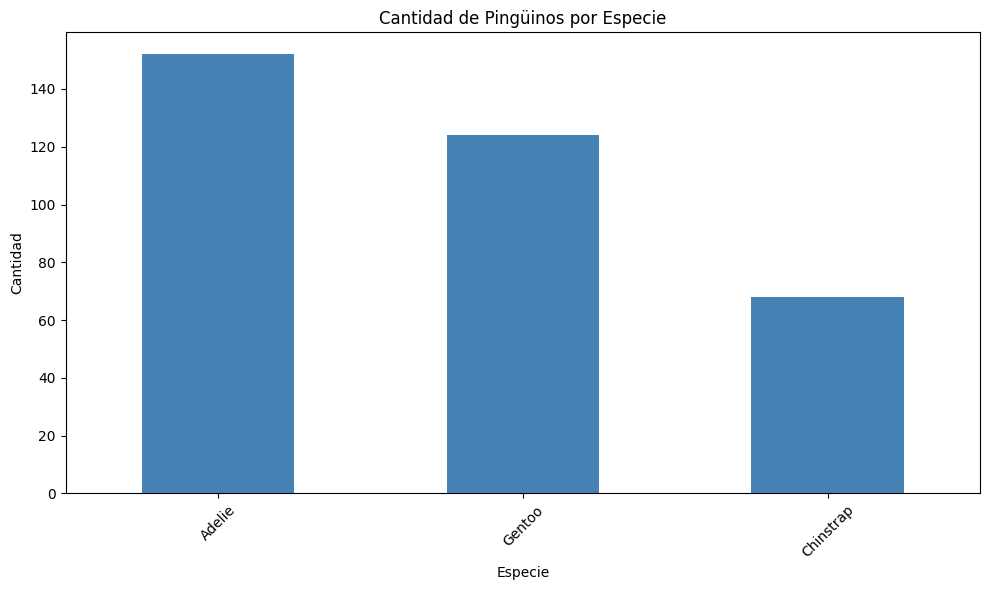

In [16]:
#valores_nulos=df_penguins[df_penguins.isna().any(axis=1)]
species_unique=df_penguins['species'].unique()
print(species_unique)
print(f"Cantidad de especies unicas : {len(species_unique)}")
#############################################################
#Saber la cantidad de especies
df_species=df_penguins.groupby('species').size().sort_values(ascending=False)

import matplotlib.pyplot as plt
# Gráfico de barras
df_species.plot(kind='bar', figsize=(10, 6), color='steelblue')
plt.title('Cantidad de Pingüinos por Especie')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**15.** What function can we use to drop the rows that have missing data?

In [17]:
df_penguins.dropna(inplace=True)
df_nulls=df_penguins[df_penguins.isna().any(axis=1)]


**16.** By default, will this modify df_penguins or will it return a copy?

**17.** How can we override the default?

**18.** Create a new DataFrame, df_penguins_full, with the missing data deleted.

In [18]:
df_penguins_full=df_penguins.copy()
df_penguins_full

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**19.** What is the average bill length of a penguin, in millimeters, in this (df_full) data set?

In [19]:
avg_bill_length=df_penguins_full['bill_length_mm'].mean().round(2)
print(f"Average bill length: {avg_bill_length}")

Average bill length: 43.99


**20.** Which of the following is most strongly correlated with bill length?  a) Body mass?  b) Flipper length?  c) Bill depth?  Show how you arrived at the answer.

In [20]:
corr1=df_penguins_full['bill_length_mm'].corr(df_penguins_full['body_mass_g'])
corr2=df_penguins_full['bill_length_mm'].corr(df_penguins_full['flipper_length_mm'])
corr3=df_penguins_full['bill_length_mm'].corr(df_penguins_full['bill_depth_mm'])
print(f"Corr1 : {corr1}")
print(f"Corr2 : {corr2}")
print(f"Corr3 : {corr3}")
lista_corr=list(zip(['bill_length_mm','body_mass_g','flipper_length_mm','bill_depth_mm'],[corr1,corr2,corr3]))
lista_corr.sort(key=lambda x: x[1],reverse=True)



Corr1 : 0.589451110176949
Corr2 : 0.6530956386670856
Corr3 : -0.22862563591302934


**21.** How could you show the median flipper length, grouped by species?

In [21]:
df_medianFlipper=df_penguins_full.groupby('species')['flipper_length_mm'].median().round(2).sort_values(ascending=False)


**22.** Which species has the longest flippers?

Gentoo

In [22]:
max_flipper_value = df_medianFlipper.max()
result_series = df_medianFlipper[df_medianFlipper == max_flipper_value]
resultado = result_series.reset_index(name='flipper_length_mm')
resultado.rename(columns={'index': 'species'}, inplace=True)
print(resultado)

  species  flipper_length_mm
0  Gentoo              216.0


**23.** Which two species have the most similar mean weight?  Show how you arrived at the answer.

In [23]:
df_mean_weight=df_penguins_full.groupby('species')['body_mass_g'].mean().round(2).sort_values(ascending=False)


# Convertir a DataFrame y ordenar
from itertools import combinations

#df_mean_weight = df_penguins_full.groupby('species')['body_mass_g'].mean().round(2).sort_values(ascending=False)

# Obtener el par con menor diferencia
pares = [(sp1, sp2, abs(df_mean_weight[sp1] - df_mean_weight[sp2]))
         for sp1, sp2 in combinations(df_mean_weight.index, 2)]

par_mas_parecido = min(pares, key=lambda x: x[2])
print(f"Especies más parecidas: {par_mas_parecido[0]} y {par_mas_parecido[1]}")
print(f"Diferencia de peso: {par_mas_parecido[2]} g")



Especies más parecidas: Chinstrap y Adelie
Diferencia de peso: 26.93000000000029 g


**24.** How could you sort the rows by bill length?

In [24]:
df_penguins_full.sort_values(by=['bill_length_mm'])

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
142,Adelie,Dream,32.1,15.5,188.0,3050.0,Female
98,Adelie,Dream,33.1,16.1,178.0,2900.0,Female
70,Adelie,Torgersen,33.5,19.0,190.0,3600.0,Female
92,Adelie,Dream,34.0,17.1,185.0,3400.0,Female
18,Adelie,Torgersen,34.4,18.4,184.0,3325.0,Female
...,...,...,...,...,...,...,...
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
215,Chinstrap,Dream,55.8,19.8,207.0,4000.0,Male
321,Gentoo,Biscoe,55.9,17.0,228.0,5600.0,Male
169,Chinstrap,Dream,58.0,17.8,181.0,3700.0,Female


**25.** How could you run the same sort in descending order?

In [25]:
df_penguins_full.sort_values(by=['bill_length_mm'],ascending=False)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
169,Chinstrap,Dream,58.0,17.8,181.0,3700.0,Female
321,Gentoo,Biscoe,55.9,17.0,228.0,5600.0,Male
215,Chinstrap,Dream,55.8,19.8,207.0,4000.0,Male
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
...,...,...,...,...,...,...,...
18,Adelie,Torgersen,34.4,18.4,184.0,3325.0,Female
92,Adelie,Dream,34.0,17.1,185.0,3400.0,Female
70,Adelie,Torgersen,33.5,19.0,190.0,3600.0,Female
98,Adelie,Dream,33.1,16.1,178.0,2900.0,Female


**26.** How could you sort by species first, then by body mass?

In [26]:
df_penguins_full.sort_values(by=['species','body_mass_g'])

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,Female
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,Female
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,Female
98,Adelie,Dream,33.1,16.1,178.0,2900.0,Female
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,Female
...,...,...,...,...,...,...,...
331,Gentoo,Biscoe,49.8,15.9,229.0,5950.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


## Selecting Rows, Columns, and Cells

Let's look at some precious stones now, and leave the poor penguins alone for a while.  Let's look at some precious stones now, and leave the poor penguins alone for a while.  

**27.** Load the Seaborn "diamonds" dataset into a Pandas dataframe named diamonds.

In [33]:
diamonds = sb.load_dataset('diamonds')




,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


**28.** Display the columns that are available.

In [34]:
display(diamonds.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

**29.** If you select a single column from the diamonds DataFrame, what will be the type of the return value?

**30.** Select the 'table' column and show its type

In [41]:
 print(diamonds['table'].dtype)

float64


**31.** Select the first ten rows of the price and carat columns ten rows of the diamonds DataFrame into a variable called subset, and display them.

In [43]:
subset=diamonds.loc[0:9,['price','carat']]
print(subset)

   price  carat
0    326   0.23
1    326   0.21
2    327   0.23
3    334   0.29
4    335   0.31
5    336   0.24
6    336   0.24
7    337   0.26
8    337   0.22
9    338   0.23


**32.** For a given column, show the code to display the datatype of the _values_ in the column?  

In [44]:
diamonds['price'].dtype

dtype('int64')

**33.** Select the first row of the diamonds DataFrame into a variable called row.

In [49]:
first_row=diamonds.head(1)
print(first_row)

   carat    cut color clarity  depth  table  price     x     y     z
0   0.23  Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43


**34.** What would you expect the data type of the row to be?  Display it.

A Pandas series

In [54]:
type_first_row=type(first_row)
print(type_first_row)

<class 'pandas.core.frame.DataFrame'>


**35.** Can you discover the names of the columns using only the row returned in #33?  Why or why not?Can you discover the names of the columns using only the row returned in #33?  Why or why not?

Yes, because a row series should have the columns as the index (See below):

In [58]:
df_33=diamonds.loc[33,:]
print(df_33)
print(df_33.index)

carat           0.23
cut        Very Good
color              E
clarity          VS1
depth           59.5
table           58.0
price            402
x               4.01
y               4.06
z                2.4
Name: 33, dtype: object
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')


**36.** Select the row with the highest priced diamond.

In [66]:
#highest_price=diamonds['price'].idxmax
#highest_price=diamonds.loc[highest_price()]
#print(highest_price)
###
highest_price=diamonds[diamonds['price']==diamonds['price'].max()]
highest_price

,carat,cut,color,clarity,depth,table,price,x,y,z
27749,2.29,Premium,I,VS2,60.8,60.0,18823,8.5,8.47,5.16


**37.** Select the row with the lowest priced diamond.

In [65]:
lowest_price=diamonds[diamonds['price']==diamonds['price'].min()]
lowest_price

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


## Some Exercises Using Time Series

**38.** Load the taxis dataset into a DataFrame, ```taxis```.

In [81]:
taxis=sb.load_dataset('taxis')

taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**39.** The 'pickup' column contains the date and time the customer picked up, but it's a string.  Add a column to the DataFrame, 'pickup_time', containing the value in 'pickup' as a DateTime.

In [85]:
type_DateTime=taxis['pickup'].dtype
taxis['pickup_time']=pd.to_datetime(taxis['pickup'])
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_time
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,2019-03-23 20:21:09
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,2019-03-04 16:11:55
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,2019-03-27 17:53:01
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,2019-03-10 01:23:59
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,2019-03-30 13:27:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,2019-03-31 09:51:53
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,2019-03-31 17:38:00
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,2019-03-23 22:55:18
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,2019-03-04 10:09:25


**40.** We have a hypothesis that as the day goes on, the tips get higher.  We'll need to wrangle the data a bit before testing this, however.  First, now that we have a datetime column, pickup_time, create a subset of it to create a new DataFrame, taxis_one_day. This new DataFrame should have values between '2019-03-23 00:06:00' (inclusive) and '2019-03-24 00:00:00' (exlusive).

In [142]:
taxis_one_day=taxis[(taxis['pickup_time']>='2019-03-23 06:00:00') & (taxis['pickup_time']<'2019-03-24 00:00:00')]
taxis_one_day


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_time
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,2019-03-23 20:21:09
8,2019-03-23 11:48:50,2019-03-23 12:06:14,1,3.63,15.0,1.00,0.0,19.30,yellow,credit card,East Harlem South,Midtown Center,Manhattan,Manhattan,2019-03-23 11:48:50
17,2019-03-23 20:50:49,2019-03-23 21:02:07,1,2.60,10.5,2.00,0.0,16.30,yellow,credit card,Midtown Center,East Harlem South,Manhattan,Manhattan,2019-03-23 20:50:49
117,2019-03-23 09:39:25,2019-03-23 09:56:45,0,3.60,15.5,3.75,0.0,22.55,yellow,credit card,Yorkville East,Penn Station/Madison Sq West,Manhattan,Manhattan,2019-03-23 09:39:25
144,2019-03-23 18:35:01,2019-03-23 18:47:39,1,3.20,12.5,2.00,0.0,17.80,yellow,credit card,UN/Turtle Bay South,East Village,Manhattan,Manhattan,2019-03-23 18:35:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6325,2019-03-23 20:52:40,2019-03-23 21:10:12,1,3.62,14.5,0.00,0.0,15.80,green,cash,Long Island City/Hunters Point,Steinway,Queens,Queens,2019-03-23 20:52:40
6331,2019-03-23 11:27:00,2019-03-23 12:20:11,1,7.67,28.0,0.00,0.0,28.00,green,cash,Jackson Heights,Maspeth,Queens,Queens,2019-03-23 11:27:00
6338,2019-03-23 18:05:38,2019-03-23 18:25:36,1,2.82,14.0,0.00,0.0,14.80,green,credit card,Claremont/Bathgate,Spuyten Duyvil/Kingsbridge,Bronx,Bronx,2019-03-23 18:05:38
6427,2019-03-23 18:26:09,2019-03-23 18:49:12,1,7.07,20.0,0.00,0.0,20.00,green,cash,Parkchester,East Harlem South,Bronx,Manhattan,2019-03-23 18:26:09


**41.** We now have a range from morning until midnight, but we to take the mean of the numeric columns, grouped at one hour intervals.  Save the result as df_means, and display it.

In [153]:
taxis_one_day['hour'] = taxis_one_day['pickup_time'].dt.strftime('%H:00:00')
df_means=taxis_one_day.groupby('hour').mean(numeric_only=True)
df_means

/tmp/ipykernel_15744/245510457.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxis_one_day['hour'] = taxis_one_day['pickup_time'].dt.strftime('%H:00:00')


,passengers,distance,fare,tip,tolls,total
hour,,,,,,
06:00:00,1.000000,0.400000,21.500000,0.000000,0.000000,23.133333
07:00:00,2.333333,0.980000,5.250000,1.165000,0.000000,9.298333
08:00:00,1.000000,0.020000,2.500000,0.000000,0.000000,3.300000
09:00:00,1.500000,1.352000,7.400000,1.674000,0.000000,12.124000
10:00:00,1.000000,1.760000,8.750000,0.727500,0.000000,12.152500
11:00:00,1.909091,2.070000,11.090909,0.803636,0.000000,14.667273
12:00:00,2.000000,2.267143,10.260000,0.645714,0.000000,13.420000
13:00:00,2.500000,1.167000,7.550000,2.074000,0.000000,12.344000
14:00:00,2.470588,4.752941,18.330000,1.945294,1.003529,24.267059


**42.** Create a simple line plot of the value "distance".  

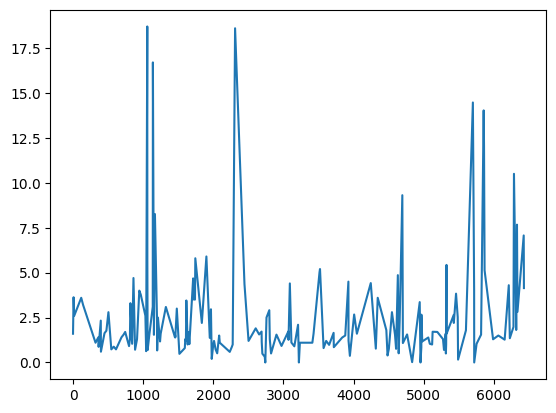

In [152]:
import matplotlib.pyplot as plt

taxis_one_day['distance'].plot()
plt.show()

**43.** Overall, do riders travel further or less far as the day progresses?

**44.** Create a new column in taxis_means, ```tip_in_percent```.  The source columns for this should be "fare" and "tip"

In [154]:
df_means['tip_in_percent']=(df_means['tip']/df_means['fare'])*100
df_means

,passengers,distance,fare,tip,tolls,total,tip_in_percent
hour,,,,,,,
06:00:00,1.000000,0.400000,21.500000,0.000000,0.000000,23.133333,0.000000
07:00:00,2.333333,0.980000,5.250000,1.165000,0.000000,9.298333,22.190476
08:00:00,1.000000,0.020000,2.500000,0.000000,0.000000,3.300000,0.000000
09:00:00,1.500000,1.352000,7.400000,1.674000,0.000000,12.124000,22.621622
10:00:00,1.000000,1.760000,8.750000,0.727500,0.000000,12.152500,8.314286
11:00:00,1.909091,2.070000,11.090909,0.803636,0.000000,14.667273,7.245902
12:00:00,2.000000,2.267143,10.260000,0.645714,0.000000,13.420000,6.293512
13:00:00,2.500000,1.167000,7.550000,2.074000,0.000000,12.344000,27.470199
14:00:00,2.470588,4.752941,18.330000,1.945294,1.003529,24.267059,10.612625


**45.** Create a new column, time_interval, as a range of integer values beginning with zero.

In [162]:
df_means['time_interval']=range(df_means.shape[0])
df_means

,passengers,distance,fare,tip,tolls,total,tip_in_percent,time_interval
hour,,,,,,,,
06:00:00,1.000000,0.400000,21.500000,0.000000,0.000000,23.133333,0.000000,0
07:00:00,2.333333,0.980000,5.250000,1.165000,0.000000,9.298333,22.190476,1
08:00:00,1.000000,0.020000,2.500000,0.000000,0.000000,3.300000,0.000000,2
09:00:00,1.500000,1.352000,7.400000,1.674000,0.000000,12.124000,22.621622,3
10:00:00,1.000000,1.760000,8.750000,0.727500,0.000000,12.152500,8.314286,4
11:00:00,1.909091,2.070000,11.090909,0.803636,0.000000,14.667273,7.245902,5
12:00:00,2.000000,2.267143,10.260000,0.645714,0.000000,13.420000,6.293512,6
13:00:00,2.500000,1.167000,7.550000,2.074000,0.000000,12.344000,27.470199,7
14:00:00,2.470588,4.752941,18.330000,1.945294,1.003529,24.267059,10.612625,8


Display the correlations between the following pairs of values:
1. tip_in_percent and distance.
1. tip_in_percent and passengers.
1. tip_in_percent and time_interval.

In [164]:
corr1=df_means['tip_in_percent'].corr(df_means['distance'])
corr2=df_means['tip_in_percent'].corr(df_means['passengers'])
corr3=df_means['tip_in_percent'].corr(df_means['time_interval'])
print(f"Corr1 : {corr1}")
print(f"Corr2 : {corr2}")
print(f"Corr3 : {corr3}")

Corr1 : 0.05806855805213837
Corr2 : 0.39614201273484234
Corr3 : 0.11904714170082598


In [165]:
correlations = {
    'tip_in_percent and distance': corr1,
    'tip_in_percent and passengers': corr2,
    'tip_in_percent and time_interval': corr3
}

strongest_correlation_pair = max(correlations, key=lambda k: abs(correlations[k]))
strongest_correlation_value = correlations[strongest_correlation_pair]

print(f"El par con la correlación más fuerte es: {strongest_correlation_pair}")
print(f"Valor de la correlación: {strongest_correlation_value:.4f}")

El par con la correlación más fuerte es: tip_in_percent and passengers
Valor de la correlación: 0.3961


**47.** Admittedly, the size of the data set is fairly small given how we've subsetted it.  But based on the values in #45, which of the three pairs show the strongest correlation.

**48.** Did our hypothesis that people tip more as the day goes on turn out to be warranted?